**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 7**
Análisis de Componentes Principales (PCA)

---

*   NOMBRE:
*   MATRÍCULA:

En esta actividad trabajarás con el archivo `automobile_dataset.csv`, basado en un conjunto de datos sobre características técnicas y especificaciones de automóviles, disponible en el repositorio UCI Machine Learning.

Los datos fueron recopilados para analizar diferentes aspectos de los vehículos y sus precios, e incluyen información sobre el fabricante, tipo de motor, dimensiones, peso, rendimiento de combustible y otras especificaciones técnicas. Los indicadores incluidos son:

* `symboling`: Nivel de riesgo del seguro del automóvil, de -3 (bajo riesgo) a +3 (alto riesgo)
* `normalized_losses`: Pérdidas normalizadas del seguro (valor numérico de la aseguradora, algunas veces faltante)
* `make`: Marca del automóvil (por ejemplo, Audi, BMW, Honda)
* `fuel_type`: Tipo de combustible (gasolina o diésel)
* `aspiration`: Tipo de aspiración del motor (normal o turbo)
* `num_doors`: Número de puertas del automóvil (dos o cuatro)
* `body_style`: Estilo de carrocería (sedán, hatchback, wagon, hardtop, convertible)
* `drive_wheels`: Tipo de tracción (fwd: delantera, rwd: trasera, 4wd: en las cuatro ruedas)
* `engine_location`: Ubicación del motor (delantero o trasero)
* `wheel_base`: Distancia entre ejes (en pulgadas)
* `length`: Largo total del automóvil (en pulgadas)
* `width`: Ancho total del automóvil (en pulgadas)
* `height`: Altura total del automóvil (en pulgadas)
* `curb_weight`: Peso del automóvil sin carga (en libras)
* `engine_type`: Tipo de motor (OHV, OHC, DOHC, etc.)
* `num_cylinders`: Número de cilindros del motor
* `engine_size`: Tamaño del motor (en cc)
* `fuel_system`: Sistema de combustible (por ejemplo, mpfi, 2bbl, 4bbl)
* `bore`: Diámetro del cilindro (en pulgadas)
* `stroke`: Carrera del pistón (en pulgadas)
* `compression_ratio`: Relación de compresión del motor
* `horsepower`: Potencia del motor (en caballos de fuerza)
* `peak_rpm`: Revoluciones máximas por minuto
* `city_mpg`: Rendimiento de combustible en ciudad (millas por galón)
* `highway_mpg`: Rendimiento de combustible en carretera (millas por galón)
* `price`: Precio del automóvil (en dólares estadounidenses) Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo.

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [1]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler

1. Descarga el archivo: `automobile_dataset.csv` y guarda, en un dataframe (`cars_df`), todos sus registros.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Al revisar los primeros registros, notarás que la columna `normalized_losses` contiene el símbolo `?`. Esto sugiere que se utilizó para indicar valores faltantes. Identifica todas las columnas que presentan este símbolo.
* Sustituye el símbolo `?` por valores faltantes (`NaN`) y convierte las columnas al tipo de dato adecuado. Esto es necesario porque la presencia del símbolo pudo haber hecho que pandas las interpretara como object, aunque en realidad no lo fueran.

In [2]:
cars_df = pd.read_csv("/Users/chicano/Documents/Tec/1-Trimestre/Ciencia y Analisis de datos/Semana 7 (Oct 20 - Oct 26)/Actividad 7 | PCA/automobile_dataset.csv")
cars_df.info()
# Columnas
# 11 Numéricas
# 15 Texto

# Símbolo a buscar
simbolo_buscar = '?'

# Identificar columnas que contienen el símbolo
columnas_con_simbolo = {}

for col in cars_df.columns:
    conteo = (cars_df[col].astype(str) == simbolo_buscar).sum()
    if conteo > 0:
        columnas_con_simbolo[col] = conteo

# Mostrar el resultado
print("Columnas que contienen el símbolo '?' y el número de ocurrencias:")
print(columnas_con_simbolo)
cars_df



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized_losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel_type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num_doors          205 non-null    object 
 6   body_style         205 non-null    object 
 7   drive_wheels       205 non-null    object 
 8   engine_location    205 non-null    object 
 9   wheel_base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb_weight        205 non-null    int64  
 14  engine_type        205 non-null    object 
 15  num_cylinders      205 non-null    int64  
 16  engine_size        205 non

,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
202,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.4,23.0,106,4800,26,27,22470


In [3]:
columnas_a_limpiar = [
    'normalized_losses', 
    'bore', 
    'stroke', 
    'horsepower', 
    'peak_rpm', 
    'price'
]

cars_df[columnas_a_limpiar] = cars_df[columnas_a_limpiar].replace('?', np.nan)
# Use pd.to_numeric with errors='coerce' to handle any remaining non-numeric values
cars_df[columnas_a_limpiar] = cars_df[columnas_a_limpiar].apply(pd.to_numeric, errors='coerce')
print("\nTipos de datos DESPUÉS de la limpieza:\n", cars_df[columnas_a_limpiar].dtypes)
print("\nPrimeras 5 filas de las columnas limpiadas:\n", cars_df[columnas_a_limpiar].head())

cars_df.info()


Tipos de datos DESPUÉS de la limpieza:
 normalized_losses    float64
bore                 float64
stroke               float64
horsepower           float64
peak_rpm             float64
price                float64
dtype: object

Primeras 5 filas de las columnas limpiadas:
    normalized_losses  bore  stroke  horsepower  peak_rpm    price
0                NaN  3.47    2.68       111.0    5000.0  13495.0
1                NaN  3.47    2.68       111.0    5000.0  16500.0
2                NaN  2.68    3.47       154.0    5000.0  16500.0
3              164.0  3.19    3.40       102.0    5500.0  13950.0
4              164.0  3.19    3.40       115.0    5500.0  17450.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized_losses  164 non-null    float64
 2   make               205 non-

# Análisis exploratorio de datos (univariado)

2. Antes de iniciar con el análisis univariado, verifica si hay valores duplicados e imprime el porcentaje de faltantes por columna.
* Obtén las estadísticas descriptivas, separado las numéricas (incluye asimetría y curtosis) y las categóricas (incluye tablas de frecuencias).
* Genera histogramas para las numéricas y diagramas de barras para las categóricas.

In [4]:
# Verificar valores duplicados
duplicados = cars_df.duplicated().sum()

# Faltantes por columna
percentaje_faltante = (cars_df.isnull().sum() / len(cars_df)) * 100

# Filtrar solo las columnas con valores faltantes y ordenar
percentaje_faltante = percentaje_faltante[percentaje_faltante > 0].sort_values(ascending=False)

print(f"Número total de filas duplicadas: {duplicados}\n")
print("Porcentaje de valores faltantes (NaN) por columna:\n")
print(percentaje_faltante.to_string())


# Estadísticas Descriptivas Numéricas (Incluye Asimetría y Curtosis) ---
df_numerico = cars_df.select_dtypes(include=np.number)
# Calcular estadísticas descriptivas
stats_descriptivas = df_numerico.describe().T
# Calcular asimetría (skewness) y curtosis (kurtosis)
asimetria = df_numerico.skew()
curtosis = df_numerico.kurt()
stats_extendidas = pd.concat([stats_descriptivas, asimetria.rename('skewness'), curtosis.rename('kurtosis')], axis=1)
print("="*80)
print("ESTADÍSTICAS DESCRIPTIVAS DE COLUMNAS NUMÉRICAS (Incluye Asimetría y Curtosis)")
print("="*80)
print(stats_extendidas.to_markdown(floatfmt=".2f"))

Número total de filas duplicadas: 0

Porcentaje de valores faltantes (NaN) por columna:

normalized_losses    20.00000
bore                  1.95122
stroke                1.95122
price                 1.95122
horsepower            0.97561
peak_rpm              0.97561
ESTADÍSTICAS DESCRIPTIVAS DE COLUMNAS NUMÉRICAS (Incluye Asimetría y Curtosis)
|                   |   count |     mean |     std |     min |     25% |      50% |      75% |      max |   skewness |   kurtosis |
|:------------------|--------:|---------:|--------:|--------:|--------:|---------:|---------:|---------:|-----------:|-----------:|
| symboling         |  205.00 |     0.83 |    1.25 |   -2.00 |    0.00 |     1.00 |     2.00 |     3.00 |       0.21 |      -0.68 |
| normalized_losses |  164.00 |   122.00 |   35.44 |   65.00 |   94.00 |   115.00 |   150.00 |   256.00 |       0.77 |       0.53 |
| wheel_base        |  205.00 |    98.76 |    6.02 |   86.60 |   94.50 |    97.00 |   102.40 |   120.90 |       1.05 |      

In [5]:
# Tablas de Frecuencias para Variables Categóricas ---
# Seleccionar columnas categóricas (object)
df_categorico = cars_df.select_dtypes(include='object')
print("\n" + "="*80)
print("TABLAS DE FRECUENCIAS DE COLUMNAS CATEGÓRICAS")
print("="*80)

for col in df_categorico.columns:
    num_valores_unicos = cars_df[col].nunique()

    print(f"\n--- Columna: {col} (Valores únicos: {num_valores_unicos}) ---")

    if num_valores_unicos <= 20: # Imprimir tabla completa si hay 20 o menos valores únicos
        counts = cars_df[col].value_counts(dropna=False)
        percentages = cars_df[col].value_counts(normalize=True, dropna=False) * 100
        frecuencia_df = pd.DataFrame({
            'Frecuencia': counts,
            'Porcentaje': percentages.round(2)
        })
        print(frecuencia_df.to_markdown())

    else: # Si hay más de 20, solo mostrar los 10 más frecuentes
        print(f"La columna tiene {num_valores_unicos} valores únicos. Se muestran los 10 más frecuentes.")
        counts = cars_df[col].value_counts(dropna=False).head(10)
        percentages = cars_df[col].value_counts(normalize=True, dropna=False).head(10) * 100
        frecuencia_df = pd.DataFrame({
            'Frecuencia': counts,
            'Porcentaje': percentages.round(2)
        })
        print(frecuencia_df.to_markdown())


TABLAS DE FRECUENCIAS DE COLUMNAS CATEGÓRICAS

--- Columna: make (Valores únicos: 22) ---
La columna tiene 22 valores únicos. Se muestran los 10 más frecuentes.
| make       |   Frecuencia |   Porcentaje |
|:-----------|-------------:|-------------:|
| toyota     |           32 |        15.61 |
| nissan     |           18 |         8.78 |
| mazda      |           17 |         8.29 |
| mitsubishi |           13 |         6.34 |
| honda      |           13 |         6.34 |
| volkswagen |           12 |         5.85 |
| subaru     |           12 |         5.85 |
| peugot     |           11 |         5.37 |
| volvo      |           11 |         5.37 |
| dodge      |            9 |         4.39 |

--- Columna: fuel_type (Valores únicos: 2) ---
| fuel_type   |   Frecuencia |   Porcentaje |
|:------------|-------------:|-------------:|
| gas         |          185 |        90.24 |
| diesel      |           20 |         9.76 |

--- Columna: aspiration (Valores únicos: 2) ---
| aspiration   | 

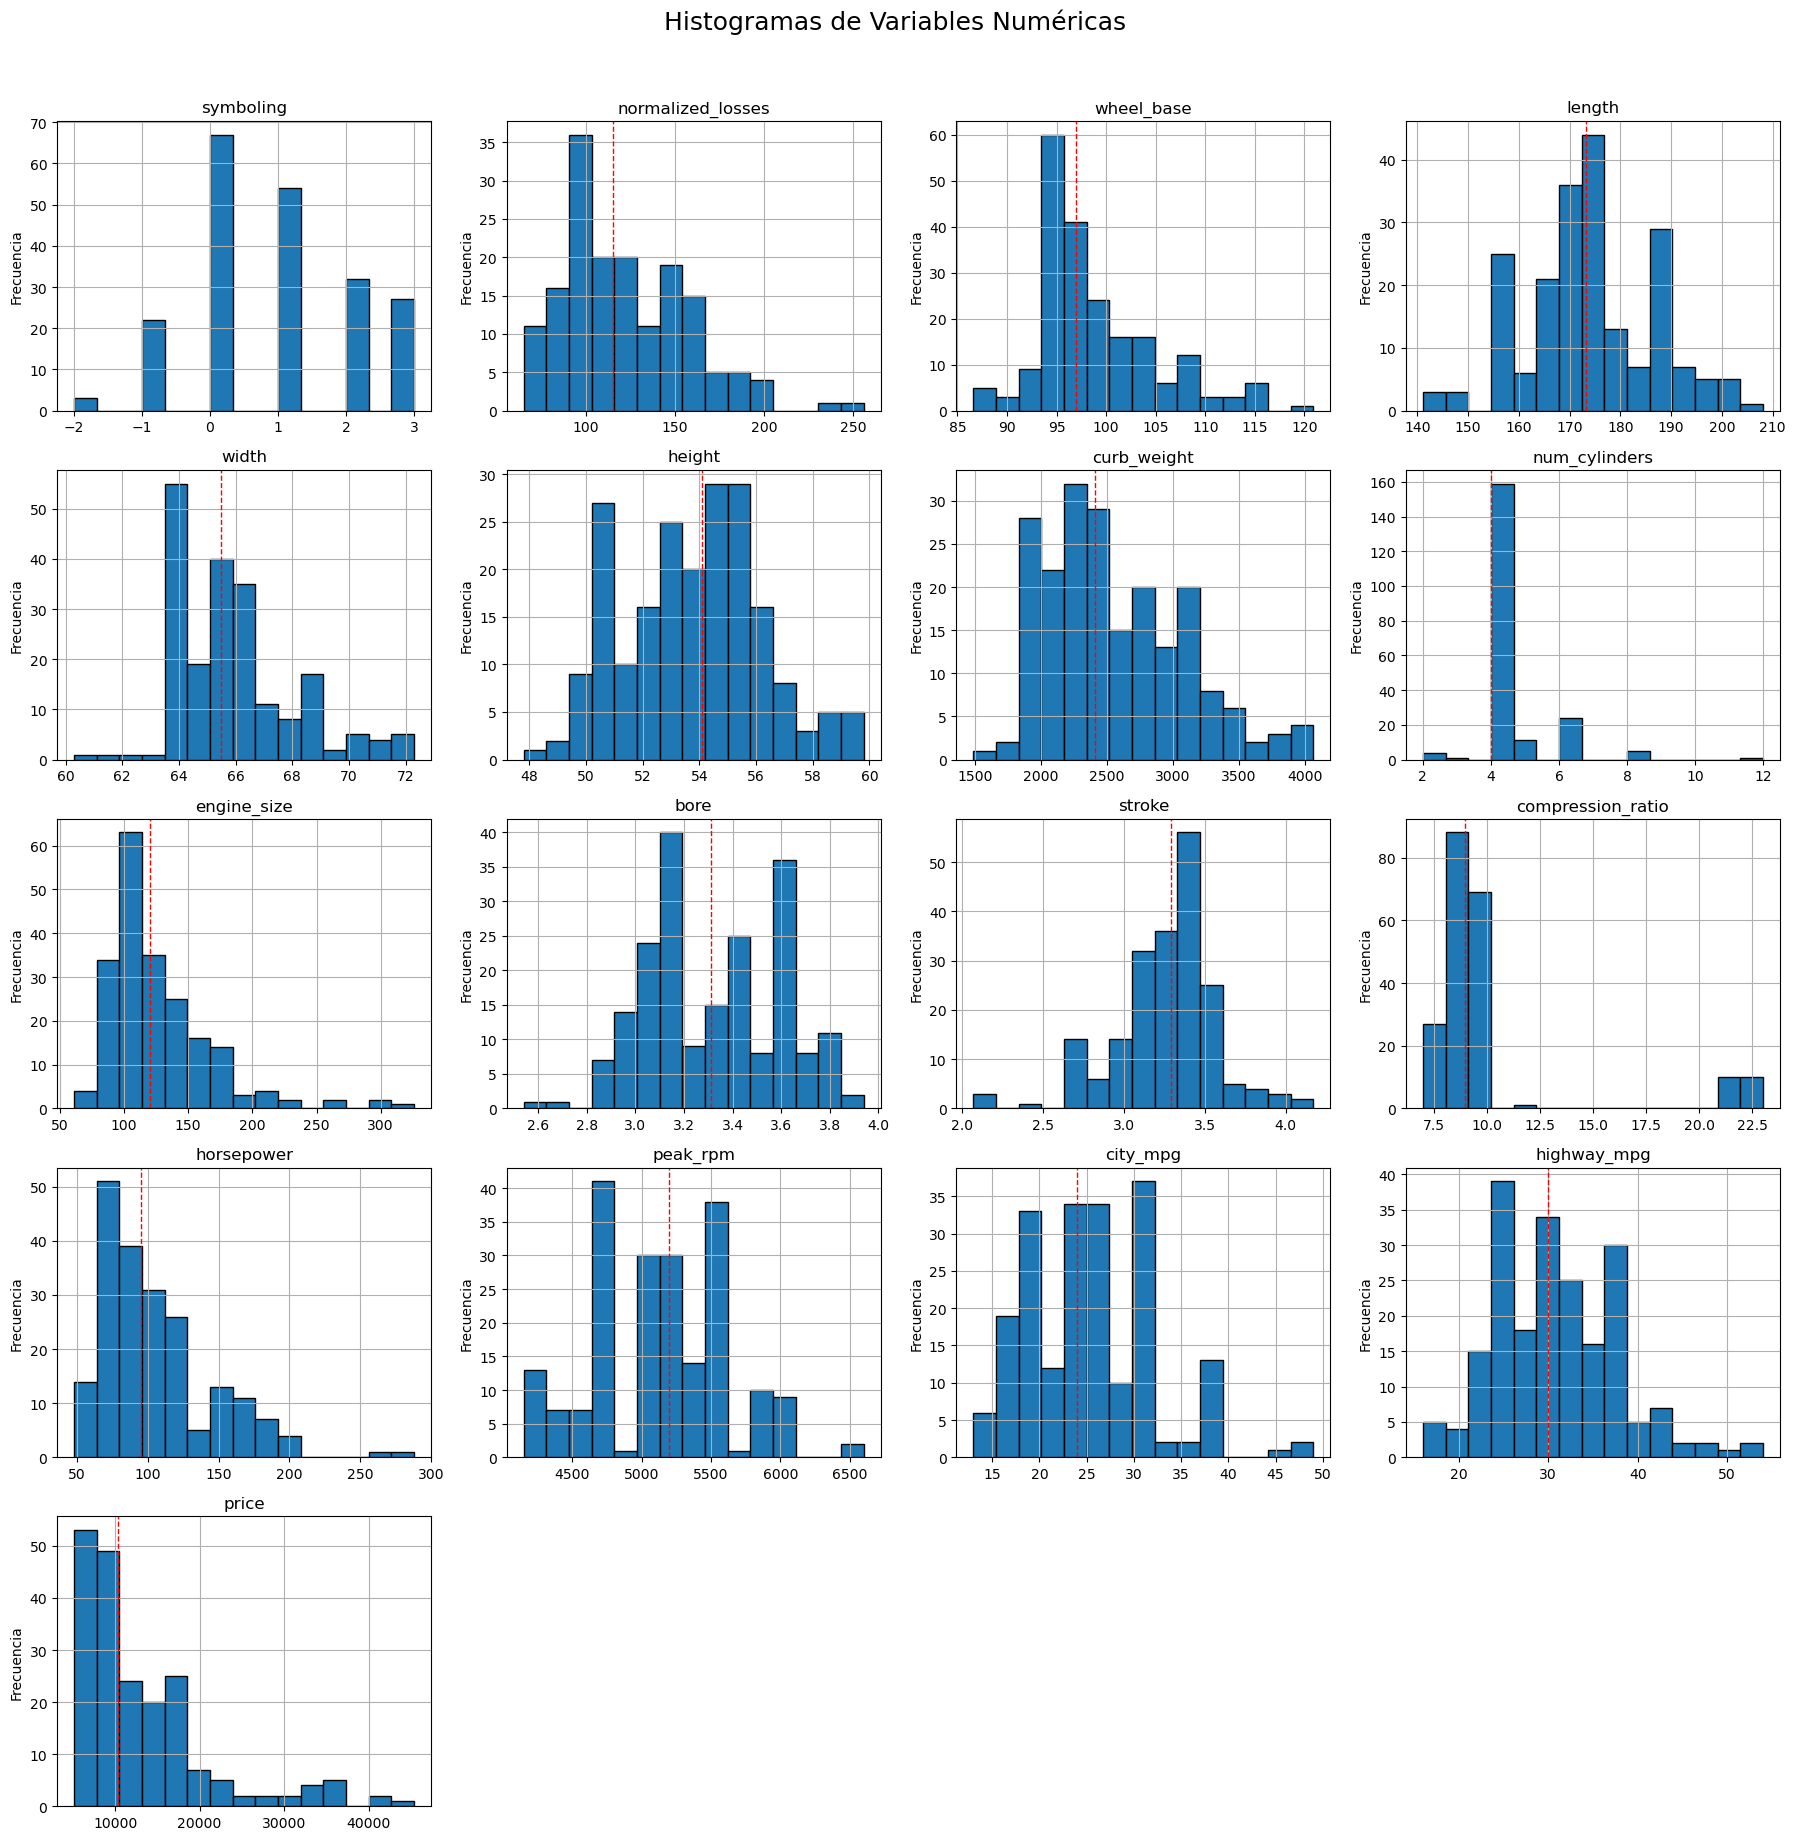

In [6]:
# --- HISTOGRAMAS PARA COLUMNAS NUMÉRICAS ---
columnas_numericas = df_numerico.columns

# Set up the grid for subplots (4x4 = 16 plots)
n_cols = 4
n_rows = (len(columnas_numericas) + n_cols - 1) // n_cols # Calculate necessary rows
fig_hist, axes_hist = plt.subplots(n_rows, n_cols, figsize=(18, 18))
axes_hist = axes_hist.flatten() # Flatten the 2D array of axes for easy iteration

fig_hist.suptitle('Histogramas de Variables Numéricas', fontsize=18, y=1.02)

for i, col in enumerate(columnas_numericas):
    if i < len(axes_hist):
        cars_df[col].hist(ax=axes_hist[i], bins=15, edgecolor='black')
        axes_hist[i].set_title(col, fontsize=12)
        axes_hist[i].set_xlabel('') # Clear x-label to reduce clutter
        axes_hist[i].set_ylabel('Frecuencia')
        # Add median line for reference, only if column is not symboling or num_cylinders (which are counts)
        if col not in ['symboling']:
            median_val = cars_df[col].median()
            axes_hist[i].axvline(median_val, color='red', linestyle='dashed', linewidth=1)
            # axes_hist[i].text(median_val*1.05, axes_hist[i].get_ylim()[1]*0.8, f'Mediana: {median_val:.1f}', color='red')

# Turn off any unused subplots
for j in range(i + 1, len(axes_hist)):
    fig_hist.delaxes(axes_hist[j])

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()
plt.close(fig_hist)



Observaciones de la distribución:
Asimetría (sesgo a la derecha): Columnas como price, engine_size, horsepower y wheel_base muestran una clara asimetría positiva (cola larga a la derecha), confirmando los hallazgos de las estadísticas descriptivas y sugiriendo la presencia de autos de alto valor/rendimiento.
Distribuciones Bimodales o Complejas: compression_ratio muestra una distribución bimodal, con un pico principal alrededor de 9 y un segundo pico cerca de 23, probablemente separando los autos de gasolina (baja compresión) y los diésel (alta compresión).
Datos Faltantes: Columnas como normalized_losses y price tienen menos barras que la muestra total (205) debido a los valores NaN que se excluyen automáticamente de los histogramas.

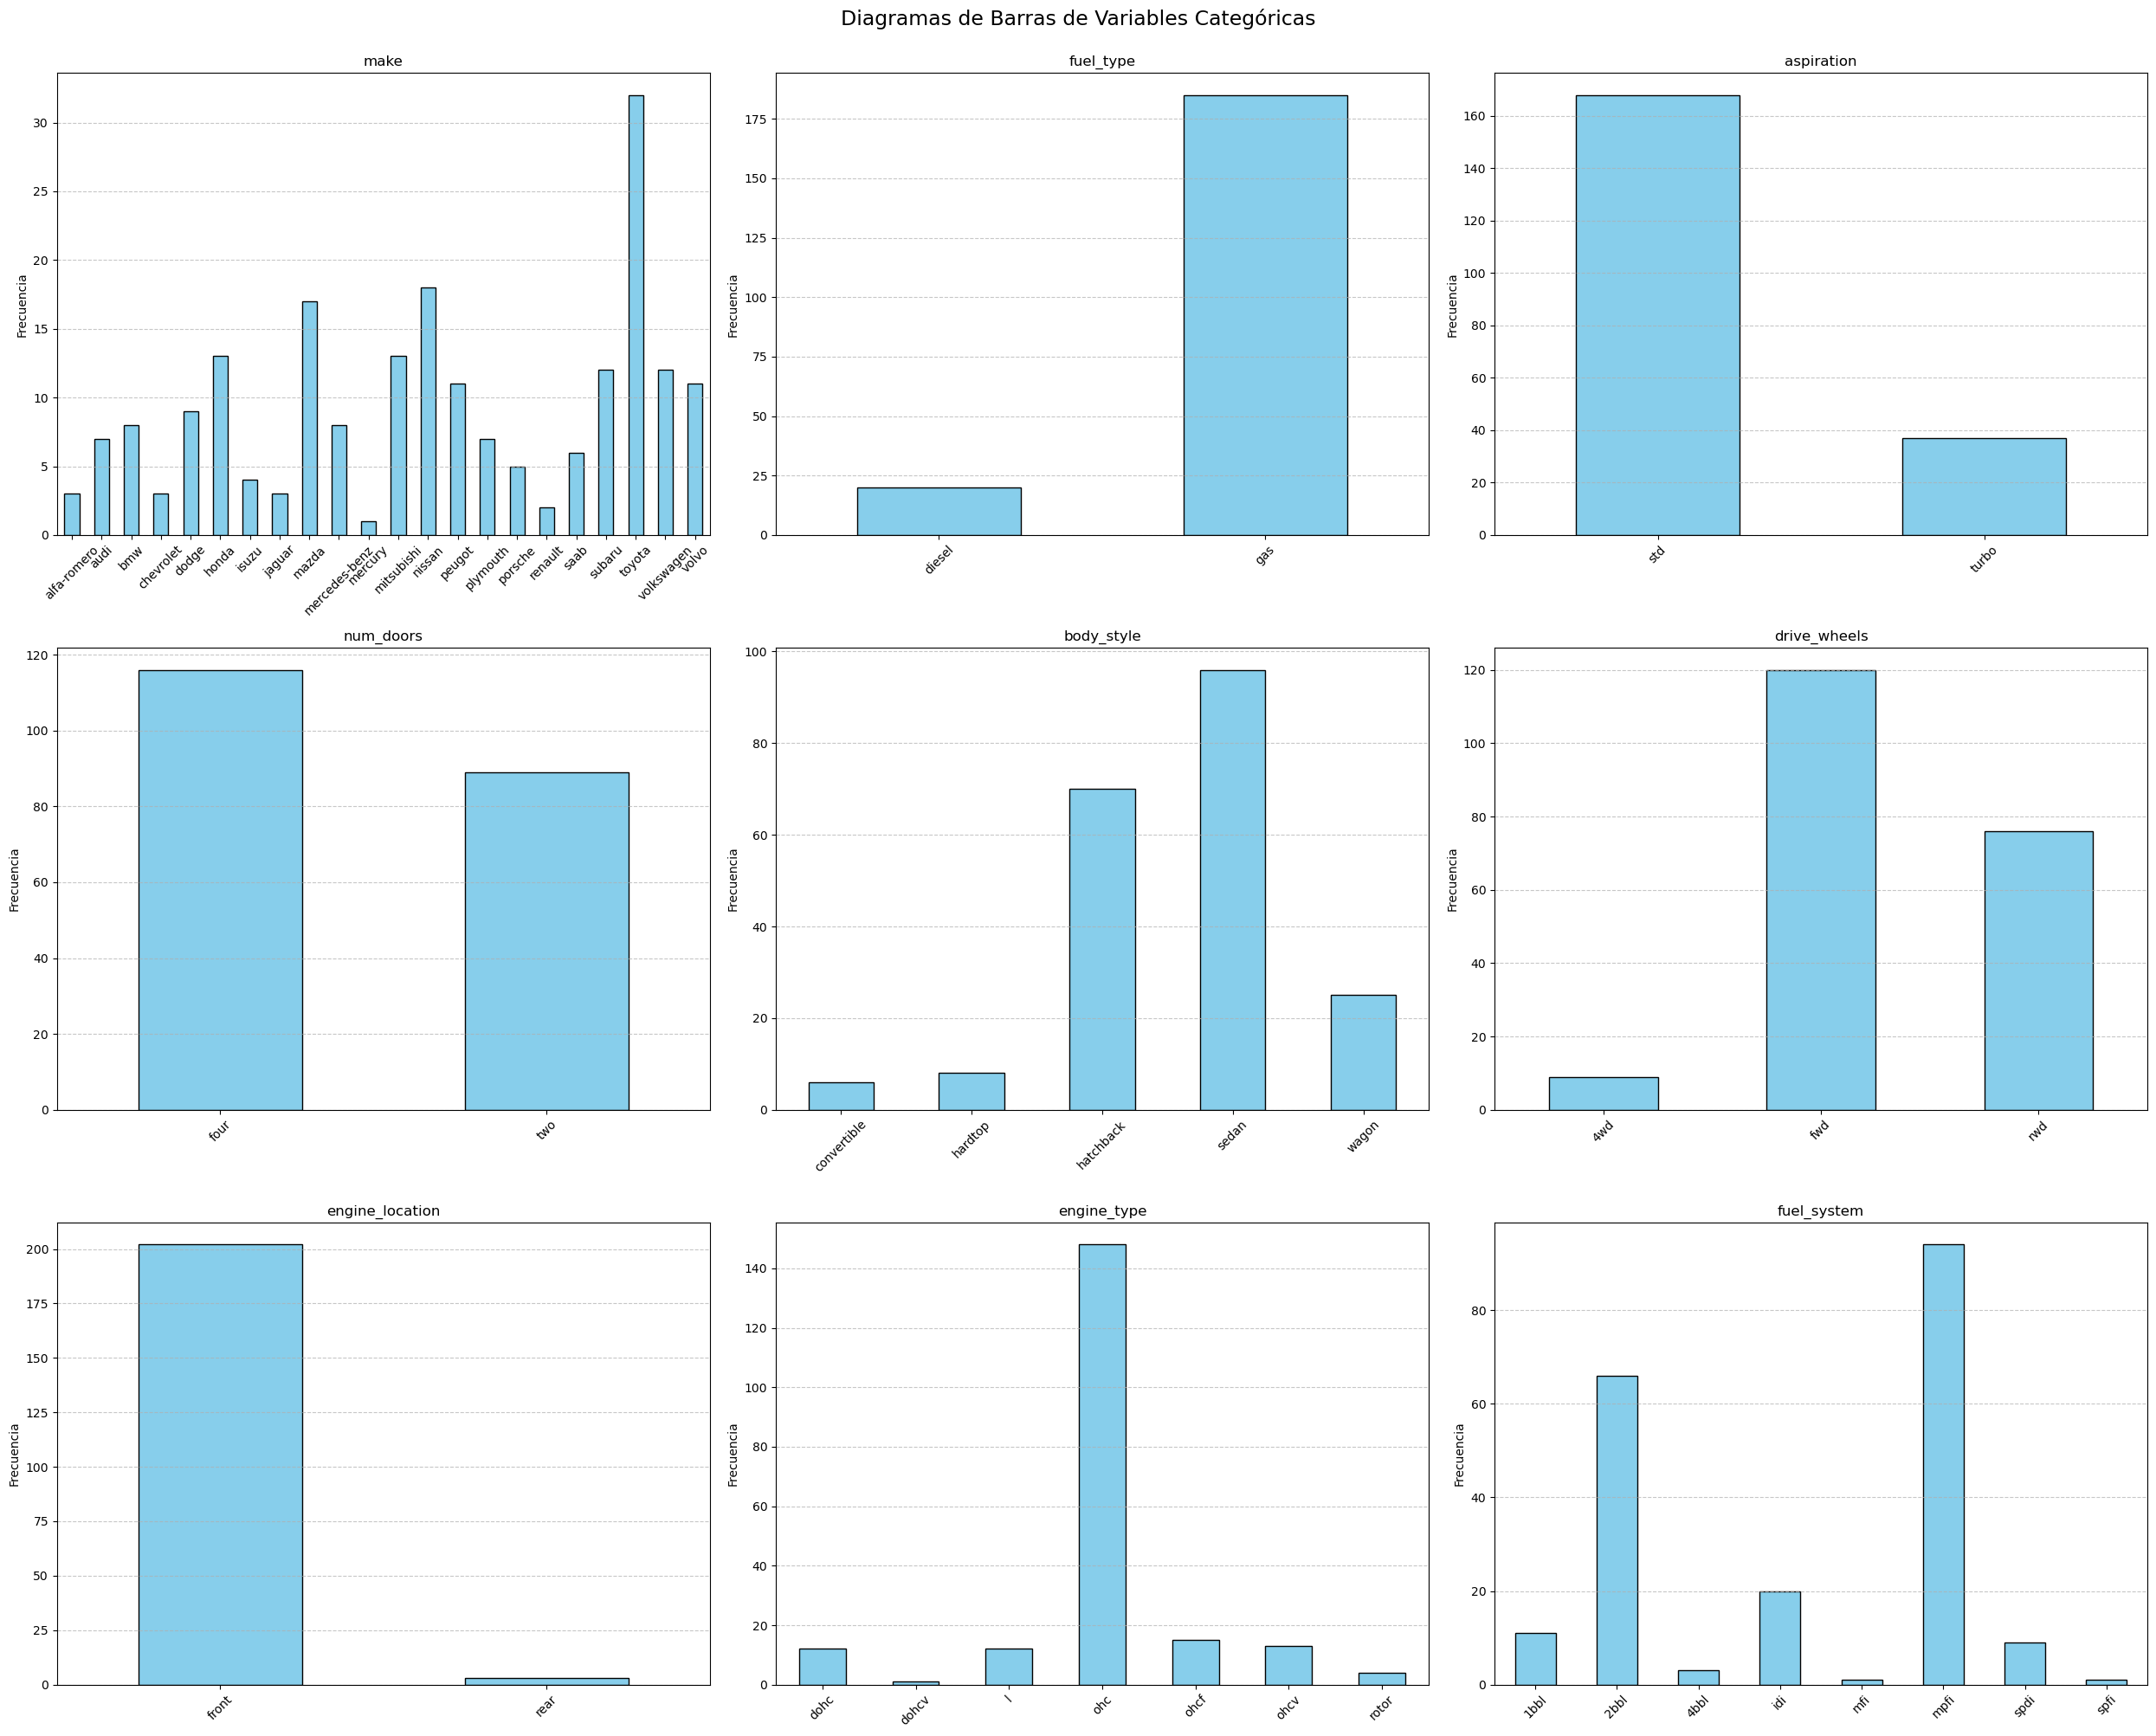

In [7]:
# --- DIAGRAMAS DE BARRAS PARA COLUMNAS CATEGÓRICAS ---
columnas_categoricas = df_categorico.columns

# Set up the grid for subplots (3x3 = 9 plots)
n_cols_cat = 3
n_rows_cat = (len(columnas_categoricas) + n_cols_cat - 1) // n_cols_cat
fig_bar, axes_bar = plt.subplots(n_rows_cat, n_cols_cat, figsize=(25, 20))
axes_bar = axes_bar.flatten()

fig_bar.suptitle('Diagramas de Barras de Variables Categóricas', fontsize=17, y=1)

for i, col in enumerate(columnas_categoricas):
    if i < len(axes_bar):
        # Calculate frequencies and sort by index (category name) for consistency
        counts = cars_df[col].value_counts().sort_index()
        counts.plot(kind='bar', ax=axes_bar[i], color='skyblue', edgecolor='black')

        axes_bar[i].set_title(col, fontsize=12)
        axes_bar[i].set_xlabel('')
        axes_bar[i].set_ylabel('Frecuencia')
        axes_bar[i].tick_params(axis='x', rotation=45, labelsize=10)
        axes_bar[i].grid(axis='y', linestyle='--', alpha=0.7)

# Turn off any unused subplots
for j in range(i + 1, len(axes_bar)):
    fig_bar.delaxes(axes_bar[j])

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()
plt.close(fig_bar)


Observaciones clave de las frecuencias:

make (Fabricante): Toyota es el fabricante más frecuente en el conjunto de datos.
fuel_type (Tipo de combustible): Hay una dominancia masiva de autos a gasolina (gas) sobre el diésel.
body_style (Estilo de carrocería): El sedán y el hatchback son los estilos más comunes.
engine_location (Ubicación del motor): Casi todos los autos tienen el motor en la parte delantera (front), con solo unos pocos casos en la parte trasera.
drive_wheels (Tracción): La tracción delantera (fwd) es la más común.

# Análisis exploratorio de datos (bivariado)

3. Genera algunos gráficos bivariados para familiarizarte con el conjunto de datos:
* Gráfico de barras apiladas normalizadas que muestra la distribución de los tipos de tracción para cada fabricante.
* Diagrama de cajas para visualizar cómo se distribuye el precio de los automóviles según el estilo de carrocería. Esto permitirá comparar la mediana, los cuartiles y la presencia de valores atípicos entre los diferentes tipos de carrocería.
* Gráfico de barras que muestre los 10 automóviles más caros, ordenados de mayor a menor precio, con cada barra diferenciada por fabricante.
* Diagrama de dispersión para explorar la relación entre el tamaño del motor y el precio de los automóviles. Diferencia con colores los puntos según el tipo de aspiración y con el tamaño de los puntos el número de puertas.

**Nota.** Debes incluir en cada gráfico una conclusión de lo observado.

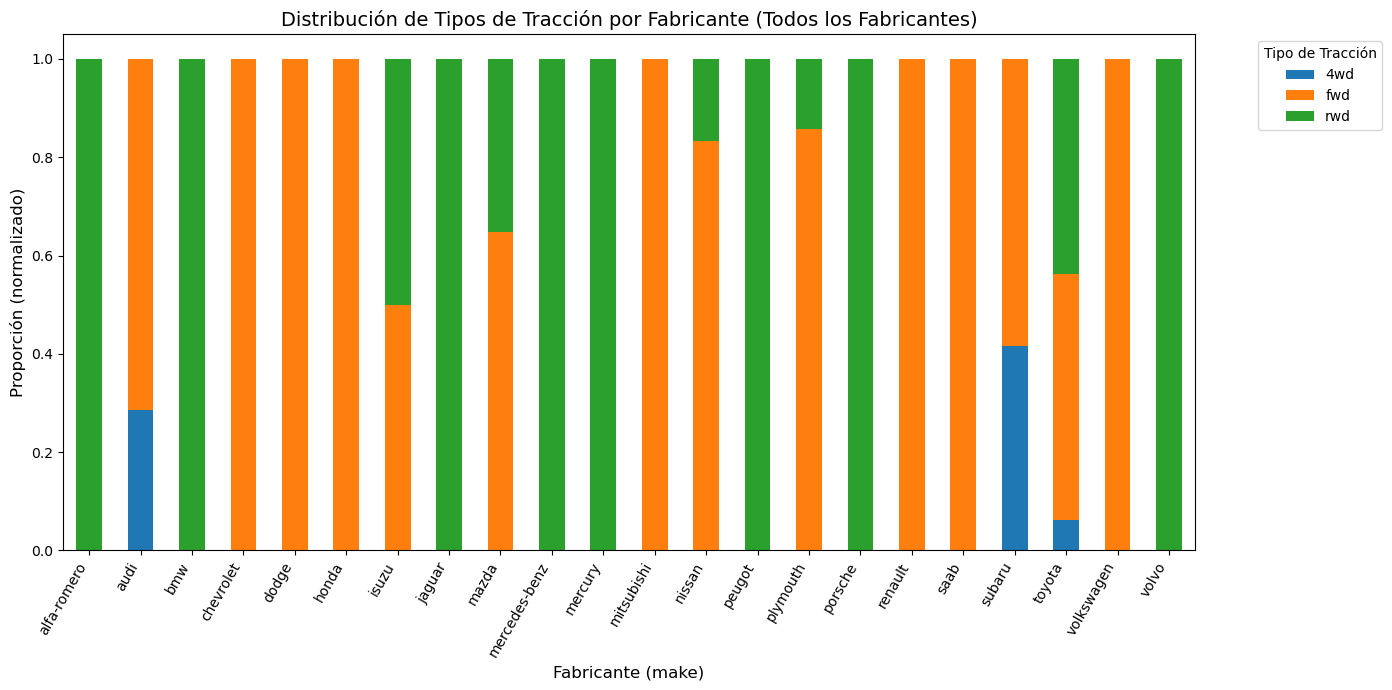

In [8]:
# Gráfico de barras apiladas normalizadas: drive_wheels por make
contingency_table = pd.crosstab(cars_df['make'], cars_df['drive_wheels'])
contingency_normalized = contingency_table.div(contingency_table.sum(axis=1), axis=0)

plt.figure(figsize=(14, 7)) # Aumentar el tamaño para acomodar más fabricantes
contingency_normalized.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('Distribución de Tipos de Tracción por Fabricante (Todos los Fabricantes)', fontsize=14)
plt.xlabel('Fabricante (make)', fontsize=12)
plt.ylabel('Proporción (normalizado)', fontsize=12)
plt.xticks(rotation=60, ha='right') # Rotar etiquetas para evitar superposición
plt.legend(title='Tipo de Tracción', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
plt.close()


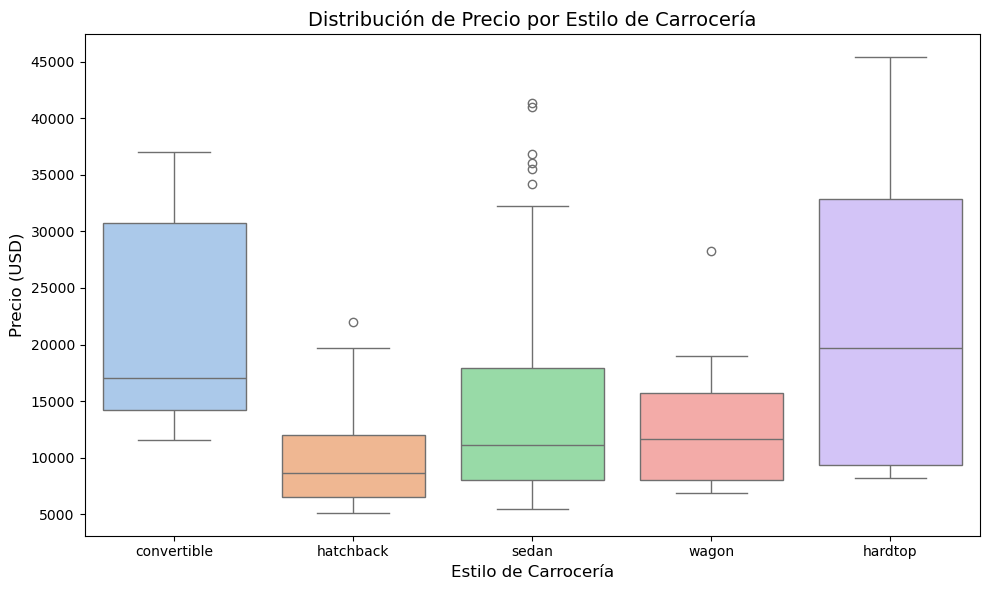

In [9]:
# Diagrama de cajas: Precio por estilo de carrocería
plt.figure(figsize=(10, 6))

sns.boxplot(
    x='body_style', 
    y='price', 
    data=cars_df, 
    hue='body_style', # <--- Se añade esta línea para asignar color por categoría
    palette='pastel', 
    legend=False      # <--- Se añade para eliminar la leyenda redundante
) 
plt.title('Distribución de Precio por Estilo de Carrocería', fontsize=14)
plt.xlabel('Estilo de Carrocería', fontsize=12)
plt.ylabel('Precio (USD)', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
plt.close()

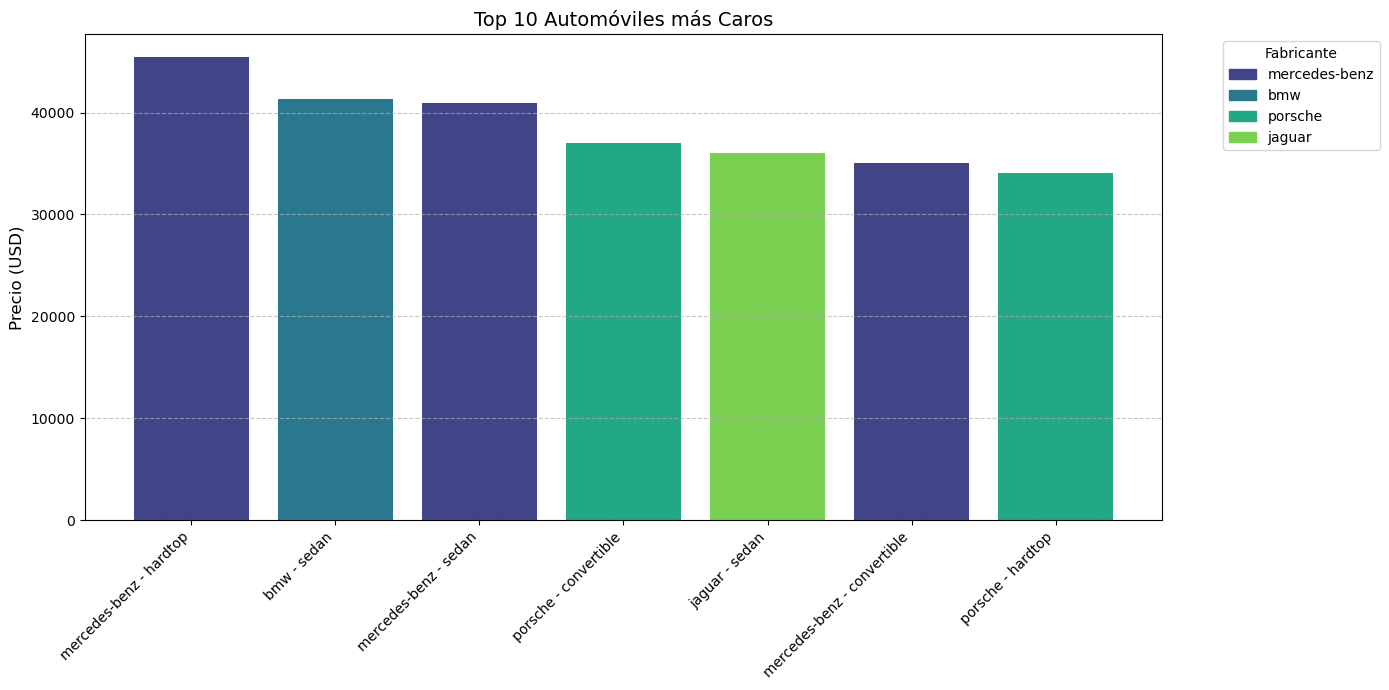

Las 10 filas de datos usadas en el gráfico (para inspección):
|     | make          | body_style   |   price |
|----:|:--------------|:-------------|--------:|
|  74 | mercedes-benz | hardtop      |   45400 |
|  16 | bmw           | sedan        |   41315 |
|  73 | mercedes-benz | sedan        |   40960 |
| 128 | porsche       | convertible  |   37028 |
|  17 | bmw           | sedan        |   36880 |
|  49 | jaguar        | sedan        |   36000 |
|  48 | jaguar        | sedan        |   35550 |
|  72 | mercedes-benz | convertible  |   35056 |
|  71 | mercedes-benz | sedan        |   34184 |
| 127 | porsche       | hardtop      |   34028 |


In [10]:
# Gráfico de barras: Top 10 automóviles más caros
# Eliminar filas con precio NaN y ordenar
df_sorted_price = cars_df.dropna(subset=['price']).sort_values('price', ascending=False).head(10).copy()

# Crear una etiqueta combinada única para el eje x, incluyendo el índice del DataFrame
# Esto garantiza que cada una de las 10 filas tenga una etiqueta única.
df_sorted_price['label'] = df_sorted_price['make'] + ' - ' + df_sorted_price['body_style']

# Definir una paleta de colores para los fabricantes (para la diferenciación visual)
unique_makes = df_sorted_price['make'].unique()
color_palette = sns.color_palette("viridis", len(unique_makes))
make_colors = dict(zip(unique_makes, color_palette))

# Crear el gráfico usando plt.bar para asegurar 10 barras distintas
plt.figure(figsize=(14, 7))

# La función .bar traza 10 barras directamente.
bars = plt.bar(
    x=df_sorted_price['label'],
    height=df_sorted_price['price'],
    color=[make_colors[make] for make in df_sorted_price['make']] # Color basado en el fabricante
)

plt.title('Top 10 Automóviles más Caros', fontsize=14)
plt.ylabel('Precio (USD)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Crear leyenda manualmente para los colores de los fabricantes
legend_handles = [plt.Rectangle((0,0),1,1, color=make_colors[make]) for make in unique_makes]
plt.legend(legend_handles, unique_makes, title='Fabricante', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()
plt.close()

print(f"Las 10 filas de datos usadas en el gráfico (para inspección):\n{df_sorted_price[['make', 'body_style', 'price']].to_markdown()}")


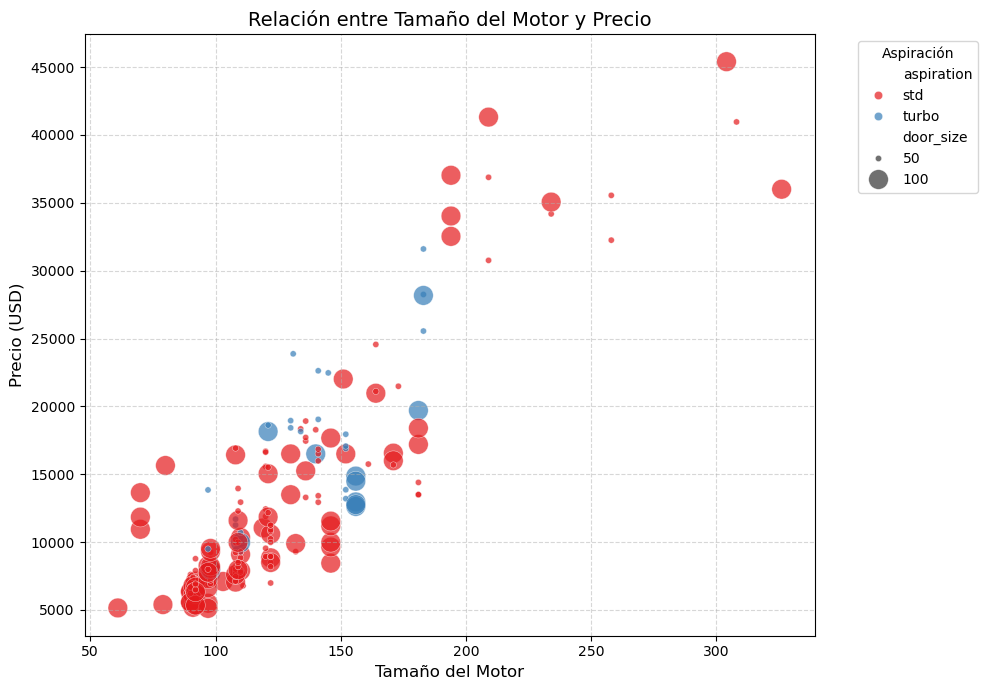

In [11]:
# Diagrama de dispersión: engine_size vs price (color=aspiration, size=num_doors)

# Mapear 'num_doors' a un tamaño numérico (e.g., 'two' to 50, 'four' to 100)
# También manejará cualquier NaN en num_doors si existiera
size_mapping = {'two': 100, 'four': 50}
cars_df['door_size'] = cars_df['num_doors'].map(size_mapping).fillna(50)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='engine_size',
    y='price',
    hue='aspiration',  # Color por tipo de aspiración
    size='door_size',    # Tamaño por número de puertas
    sizes=(20, 200),     # Rango de tamaños
    data=cars_df.dropna(subset=['price', 'engine_size']), # Eliminar NaNs relevantes para el plot
    palette='Set1',
    alpha=0.7
)
plt.title('Relación entre Tamaño del Motor y Precio', fontsize=14)
plt.xlabel('Tamaño del Motor', fontsize=12)
plt.ylabel('Precio (USD)', fontsize=12)
plt.legend(title='Aspiración', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
plt.close()

4. Genera un mapa de calor de la matriz de correlación entre las variables numéricas del conjunto de datos, mostrando los valores de correlación en cada celda.
* ¿Cuáles son las tres variables más correlacionadas con el precio?

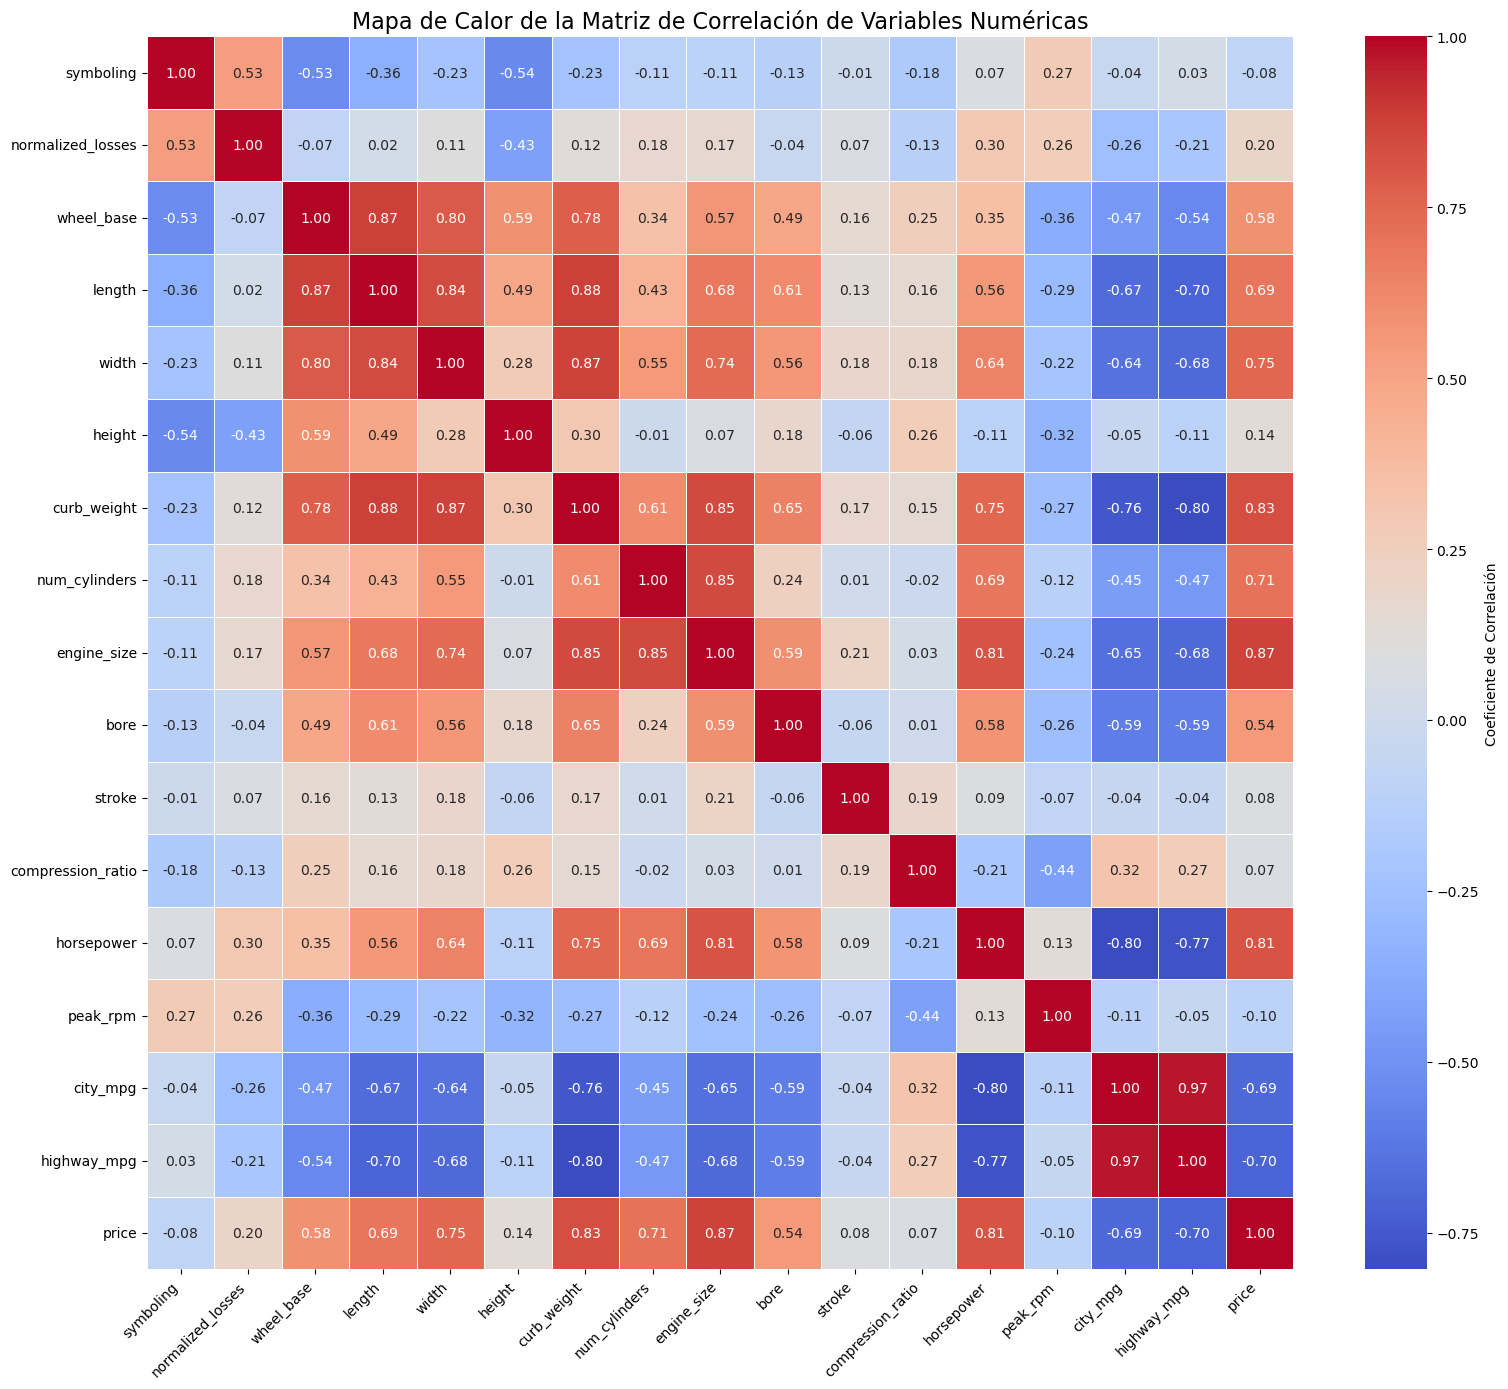

In [12]:
# Calcular la matriz de correlación
corr_matrix = df_numerico.corr()

plt.figure(figsize=(16, 14))
sns.heatmap(
    corr_matrix,
    annot=True,          # Mostrar los valores de correlación en las celdas
    fmt=".2f",           # Formato con dos decimales
    cmap='coolwarm',     # Esquema de color
    linewidths=.5,       # Líneas entre celdas
    cbar_kws={'label': 'Coeficiente de Correlación'}
)
plt.title('Mapa de Calor de la Matriz de Correlación de Variables Numéricas', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
plt.close()

Las tres variables númericas con mayor correlación con el precio son:
Variable	Coeficiente de Correlación
engine_size	         0.872
curb_weight	         0.834
horsepower	         0.811

En el análisis de correlación se observa que existen muchos pares de variables altamente correlacionadas, lo que puede afectar el desempeño de los modelos de regresión. PCA resulta útil no solo para reducir la dimensionalidad, sino también porque los componentes principales son ortogonales entre sí, es decir, tienen correlación cero, evitando problemas de multicolinealidad. Esto lo podrás comprobrar más adelante.

# Ingeniería de características

5. Realiza las siguientes operaciones de ingeniería de características en las variables numéricas:
* Aplica `SimpleImputer` para tratar los valores faltantes, justificando la estrategia de imputación seleccionada.
* Considera `price` como la variable objetivo y guárdala en `y`. Separa los predictores numéricos en `X`. Con base en estos datos, ¿cuántos componentes principales se generarán al aplicar PCA?
* Escala los valores de `X` para que todas las variables contribuyan equitativamente y ninguna domine el análisis por tener una escala mayor.

PCA está diseñado principalmente para variables numéricas y funciona encontrando combinaciones lineales de las variables originales que capturan la mayor varianza en los datos. Normalmente se recomienda eliminar las variables categóricas antes de aplicar PCA y luego concatenarlas nuevamente con los resultados de PCA si se desea.

In [13]:
# Identificar solo las columnas que tienen valores faltantes
cols_with_nans = df_numerico.columns[df_numerico.isnull().any()].tolist()
# 2. Definir la estrategia de imputación (Mediana)
# Justificación: Se utiliza la mediana porque las estadísticas descriptivas mostraron que varias variables
# (como 'price', 'engine_size', 'horsepower') tienen una fuerte asimetría positiva (skewness > 1).
# La mediana es robusta a los valores atípicos y al sesgo (asimetría), lo que la convierte en una 
# mejor representante del "valor central" para rellenar los huecos que la media.

imputer = SimpleImputer(strategy='median')

# 3. Aplicar la imputación
# Convertir a array, aplicar el imputer, y convertir de vuelta a DataFrame
df_imputed_array = imputer.fit_transform(df_numerico)
df_imputed = pd.DataFrame(df_imputed_array, columns=df_numerico.columns)

# 4. Verificar la imputación (comprobando los NaNs)
nans_before = cars_df[cols_with_nans].isnull().sum()
nans_after = df_imputed[cols_with_nans].isnull().sum()

print("="*60)
print("JUSTIFICACIÓN DE LA ESTRATEGIA")
print("="*60)
print("Estrategia Seleccionada: Mediana ('median').")
print("Razón: Las variables como 'price', 'horsepower' y 'engine_size' mostraron una 'asimetría (skewness) positiva' y una alta 'curtosis' en el análisis univariado. La mediana es una medida de tendencia central 'robusta' a los valores atípicos y distribuciones sesgadas, lo que la hace menos propensa a distorsionar la distribución original que la media.")
print("="*60)
print("VERIFICACIÓN DE LA IMPUTACIÓN")
print("="*60)
print("Valores faltantes antes de la imputación:")
print(nans_before.to_markdown())
print("\nValores faltantes después de la imputación (deberían ser 0):")
print(nans_after.to_markdown())


JUSTIFICACIÓN DE LA ESTRATEGIA
Estrategia Seleccionada: Mediana ('median').
Razón: Las variables como 'price', 'horsepower' y 'engine_size' mostraron una 'asimetría (skewness) positiva' y una alta 'curtosis' en el análisis univariado. La mediana es una medida de tendencia central 'robusta' a los valores atípicos y distribuciones sesgadas, lo que la hace menos propensa a distorsionar la distribución original que la media.
VERIFICACIÓN DE LA IMPUTACIÓN
Valores faltantes antes de la imputación:
|                   |   0 |
|:------------------|----:|
| normalized_losses |  41 |
| bore              |   4 |
| stroke            |   4 |
| horsepower        |   2 |
| peak_rpm          |   2 |
| price             |   4 |

Valores faltantes después de la imputación (deberían ser 0):
|                   |   0 |
|:------------------|----:|
| normalized_losses |   0 |
| bore              |   0 |
| stroke            |   0 |
| horsepower        |   0 |
| peak_rpm          |   0 |
| price             |

In [14]:
# Definir X y y

# Variable objetivo (y)
y = df_imputed['price']

# Predictores numéricos (X) - Se excluye 'price'
X = df_imputed.drop(columns=['price'])

# Contar el número de características en X
num_features = X.shape[1]

print(f"Número de variables predictoras (columnas en X): {num_features}")
print(f"Variables Predictoras (X):\n{X.columns.tolist()}")


Número de variables predictoras (columnas en X): 16
Variables Predictoras (X):
['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'num_cylinders', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg']


In [15]:
# Escala los valores de X para que todas las variables contribuyan equitativamente y ninguna domine el análisis por tener una escala mayor.
# Escalar los valores de X
# Se utiliza StandardScaler para asegurar que la media sea 0 y la desviación estándar 1,
# permitiendo que todas las variables contribuyan equitativamente en PCA.
#scaler = StandardScaler()
#X_scaled_array = scaler.fit_transform(X)

robust_scaler = RobustScaler()
X_robust_scaled_array = robust_scaler.fit_transform(X)

# Convertir el array escalado de vuelta a un DataFrame
# X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns)
X_robust_scaled = pd.DataFrame(X_robust_scaled_array, columns=X.columns)
print("Predictores (X) Escalandos (RobustScaler):")
#print(X_scaled.head().to_markdown(floatfmt=".3f"))
print(X_robust_scaled.head().to_markdown(floatfmt=".3f"))
print("-" * 50)
#print(f"Media de la primera columna ('symboling') después del escalado: {X_scaled['symboling'].mean():.10f}")
print(f"Media de la primera columna ('symboling') después del escalado: {X_robust_scaled['symboling'].mean():.10f}")
#print(f"Desviación estándar de la primera columna ('symboling') después del escalado: {X_scaled['symboling'].std():.10f}")
print(f"Desviación estándar de la primera columna ('symboling') después del escalado: {X_robust_scaled['symboling'].std():.10f}")

X_robust_scaled

Predictores (X) Escalandos (RobustScaler):
|    |   symboling |   normalized_losses |   wheel_base |   length |   width |   height |   curb_weight |   num_cylinders |   engine_size |   bore |   stroke |   compression_ratio |   horsepower |   peak_rpm |   city_mpg |   highway_mpg |
|---:|------------:|--------------------:|-------------:|---------:|--------:|---------:|--------------:|----------------:|--------------:|-------:|---------:|--------------------:|-------------:|-----------:|-----------:|--------------:|
|  0 |       1.000 |               0.000 |       -1.063 |   -0.262 |  -0.500 |   -1.514 |         0.170 |           0.000 |         0.227 |  0.372 |   -2.033 |               0.000 |        0.348 |     -0.286 |     -0.273 |        -0.333 |
|  1 |       1.000 |               0.000 |       -1.063 |   -0.262 |  -0.500 |   -1.514 |         0.170 |           0.000 |         0.227 |  0.372 |   -2.033 |               0.000 |        0.348 |     -0.286 |     -0.273 |        -0.333 |
|

,symboling,normalized_losses,wheel_base,length,width,height,curb_weight,num_cylinders,engine_size,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg
0,1.0,0.000000,-1.063291,-0.261905,-0.500000,-1.514286,0.169620,0.0,0.227273,0.372093,-2.033333,0.000,0.347826,-0.285714,-0.272727,-0.333333
1,1.0,0.000000,-1.063291,-0.261905,-0.500000,-1.514286,0.169620,0.0,0.227273,0.372093,-2.033333,0.000,0.347826,-0.285714,-0.272727,-0.333333
2,0.0,0.000000,-0.316456,-0.119048,0.000000,-0.485714,0.517722,2.0,0.727273,-1.465116,0.600000,0.000,1.282609,-0.285714,-0.454545,-0.444444
3,0.5,1.361111,0.354430,0.202381,0.250000,0.057143,-0.097468,0.0,-0.250000,-0.279070,0.366667,1.250,0.152174,0.428571,0.000000,0.000000
4,0.5,1.361111,0.303797,0.202381,0.321429,0.057143,0.518987,1.0,0.363636,-0.279070,0.366667,-1.250,0.434783,0.428571,-0.545455,-0.888889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1.0,-0.555556,1.531646,0.928571,1.214286,0.400000,0.681013,0.0,0.477273,1.093023,-0.466667,0.625,0.413043,0.285714,-0.090909,-0.222222
201,-1.0,-0.555556,1.531646,0.928571,1.178571,0.400000,0.803797,0.0,0.477273,1.093023,-0.466667,-0.375,1.413043,0.142857,-0.454545,-0.555556
202,-1.0,-0.555556,1.531646,0.928571,1.214286,0.400000,0.756962,2.0,1.204545,0.627907,-1.400000,-0.250,0.847826,0.428571,-0.545455,-0.777778
203,-1.0,-0.555556,1.531646,0.928571,1.214286,0.400000,1.016456,2.0,0.568182,-0.697674,0.366667,17.500,0.239130,-0.571429,0.181818,-0.333333


6. Aplica `PCA` a los datos escalados para proyectarlos en el nuevo espacio de vectores.
* Asigna nombres descriptivos a los componentes principales en el dataframe resultante, utilizando la convención PC1, PC2, PC3, y así sucesivamente.
* Genera un mapa de calor con la matriz de correlaciones de los componentes principales para verificar que sean independientes entre sí.

In [16]:
# Aplicar PCA a los datos escalados
#n_components = X_scaled.shape[1] # 16 componentes
n_components = X_robust_scaled.shape[1] # 16 componentes
pca = PCA(n_components=n_components)

# Aplicar PCA para proyectar los datos
#X_pca_array = pca.fit_transform(X_scaled)
X_pca_array = pca.fit_transform(X_robust_scaled)

# Asignar nombres descriptivos (PC1, PC2, PC3, PCK)
component_names = [f'PC{i+1}' for i in range(n_components)]
X_pca = pd.DataFrame(X_pca_array, columns=component_names)


# 5. Mostrar resultados
print("PCA aplicado. Número de componentes generados:", X_pca.shape[1])
print("Primeras filas del DataFrame de Componentes Principales (X_pca):")
print(X_pca.head().to_markdown(floatfmt=".3f"))

PCA aplicado. Número de componentes generados: 16
Primeras filas del DataFrame de Componentes Principales (X_pca):
|    |    PC1 |    PC2 |   PC3 |    PC4 |    PC5 |    PC6 |    PC7 |   PC8 |    PC9 |   PC10 |   PC11 |   PC12 |   PC13 |   PC14 |   PC15 |   PC16 |
|---:|-------:|-------:|------:|-------:|-------:|-------:|-------:|------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|
|  0 | -1.672 | -0.723 | 0.518 | -2.005 | -0.520 | -1.488 | -0.903 | 0.189 | -0.552 | -0.357 | -0.327 |  0.249 |  0.254 |  0.301 | -0.065 | -0.007 |
|  1 | -1.672 | -0.723 | 0.518 | -2.005 | -0.520 | -1.488 | -0.903 | 0.189 | -0.552 | -0.357 | -0.327 |  0.249 |  0.254 |  0.301 | -0.065 | -0.007 |
|  2 | -1.500 |  1.154 | 1.224 | -0.108 |  1.517 |  0.152 |  0.581 | 0.808 | -0.627 | -0.857 |  0.667 |  0.441 | -0.056 |  0.126 | -0.094 | -0.090 |
|  3 | -0.225 | -0.294 | 0.871 |  0.495 | -1.032 |  0.567 |  0.392 | 0.341 |  0.088 |  0.211 |  0.033 | -0.007 |  0.026 | -0.263 | -0.098 | 

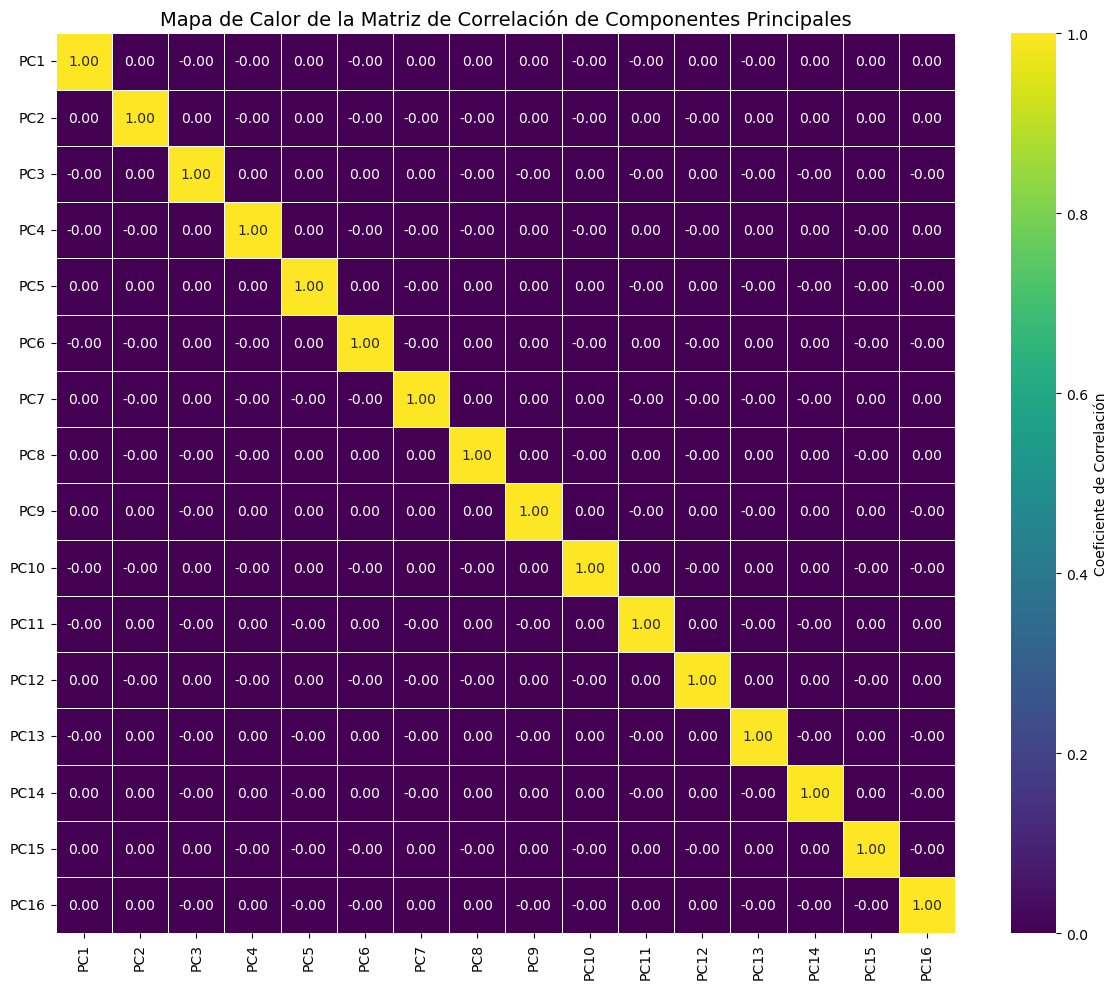

In [17]:
# Generar mapa de calor de correlaciones

# Calcular la matriz de correlación de los componentes
pca_corr_matrix = X_pca.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    pca_corr_matrix,
    annot=True,          # Mostrar los valores de correlación en las celdas
    fmt=".2f",           # Formato con dos decimales
    cmap='viridis',      # Esquema de color
    linewidths=.5,       # Líneas entre celdas
    cbar_kws={'label': 'Coeficiente de Correlación'}
)
plt.title('Mapa de Calor de la Matriz de Correlación de Componentes Principales', fontsize=14)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
plt.close()

7. Obtén el porcentaje de varianza explicada por cada componente.
* Grafica la curva de varianza acumulada para determinar el número mínimo de componentes principales que explican más del 90% de la varianza total.

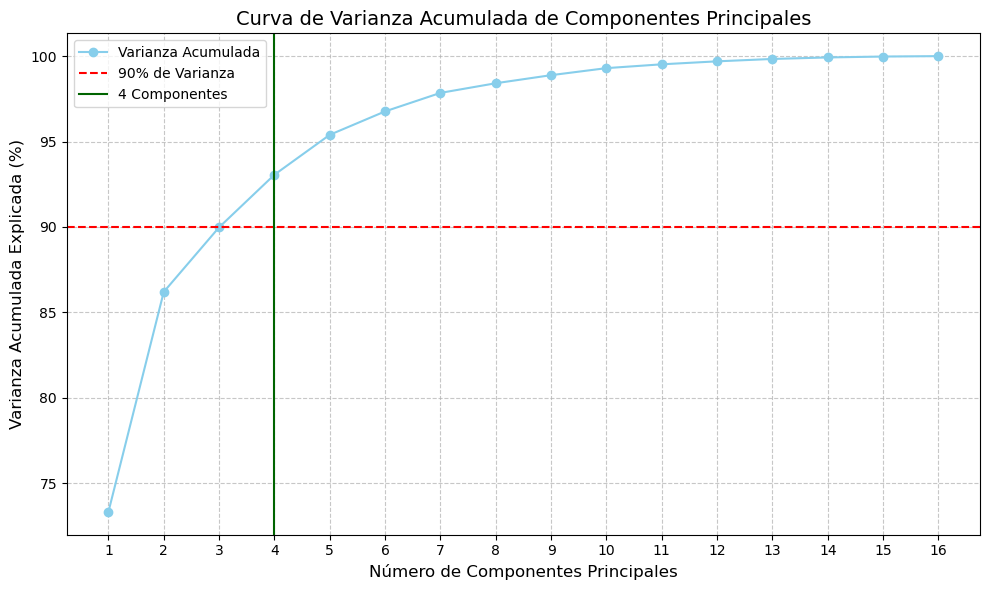


Porcentaje de Varianza Explicada por Cada Componente:
|    | Componente   |   Varianza Explicada (%) |
|---:|:-------------|-------------------------:|
|  0 | PC1          |                    73.32 |
|  1 | PC2          |                    12.88 |
|  2 | PC3          |                     3.78 |
|  3 | PC4          |                     3.08 |
|  4 | PC5          |                     2.34 |
|  5 | PC6          |                     1.37 |
|  6 | PC7          |                     1.08 |
|  7 | PC8          |                     0.56 |
|  8 | PC9          |                     0.47 |
|  9 | PC10         |                     0.41 |
| 10 | PC11         |                     0.22 |
| 11 | PC12         |                     0.17 |
| 12 | PC13         |                     0.14 |
| 13 | PC14         |                     0.09 |
| 14 | PC15         |                     0.05 |
| 15 | PC16         |                     0.02 |
--------------------------------------------------
Número mínim

In [18]:
# Varianza explicada por componente
explained_variance_ratio = pca.explained_variance_ratio_
explained_variance_percentage = explained_variance_ratio * 100
variance_df = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(n_components)],
    'Varianza Explicada (%)': explained_variance_percentage
})

# Varianza acumulada
cumulative_variance = np.cumsum(explained_variance_ratio) * 100

# Determinar el número mínimo de componentes para el 90%
threshold = 90
n_components_90 = np.where(cumulative_variance >= threshold)[0][0] + 1
cumulative_variance_90 = cumulative_variance[n_components_90 - 1]

# Graficar la curva de varianza acumulada
plt.figure(figsize=(10, 6))
plt.plot(range(1, n_components + 1), cumulative_variance, marker='o', linestyle='-', color='skyblue', label='Varianza Acumulada')
plt.title('Curva de Varianza Acumulada de Componentes Principales', fontsize=14)
plt.xlabel('Número de Componentes Principales', fontsize=12)
plt.ylabel('Varianza Acumulada Explicada (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Marcar el umbral del 90%
plt.axhline(threshold, color='red', linestyle='--', label=f'{threshold}% de Varianza')
plt.axvline(n_components_90, color='darkgreen', linestyle='-', label=f'{n_components_90} Componentes')

plt.legend()
plt.xticks(range(1, n_components + 1, 1))
plt.tight_layout()
plt.show()
plt.close()

print("\nPorcentaje de Varianza Explicada por Cada Componente:")
print(variance_df.to_markdown(floatfmt=".2f"))
print("-" * 50)
print(f"Número mínimo de componentes para >{threshold}% de varianza:")
print(f"{n_components_90} componentes (explican {cumulative_variance_90:.2f}% de la varianza total).")


8. Imprime la información de los componentes seleccionados (cargas o pesos de las variables originales) para interpretar qué variables contribuyen más a cada componente principal.
* Dibuja un diagrama de barras que muestre qué variables originales aportan más al primer componente principal (PC1), para visualizar su influencia relativa.

Cargas (loadings) - pesos de cada variable original en los componentes:



,PC1,PC2,PC3,PC4
symboling,-0.024,-0.060,0.361,-0.096
normalized_losses,-0.022,0.034,0.523,-0.088
wheel_base,0.040,0.264,-0.278,0.174
length,0.025,0.296,-0.191,0.111
width,0.029,0.318,-0.055,0.074
height,0.038,0.071,-0.448,0.106
curb_weight,0.021,0.297,-0.037,0.035
num_cylinders,-0.004,0.391,0.204,-0.363
engine_size,0.006,0.422,0.126,-0.061
bore,0.001,0.194,-0.119,-0.019


Top 5 variables más influyentes en {pc}:
normalized_losses    0.523420
height               0.447676
symboling            0.361378
stroke               0.353085
wheel_base           0.278284
Name: PC3, dtype: float64
Top 5 variables más influyentes en {pc}:
compression_ratio    0.992050
peak_rpm             0.061117
highway_mpg          0.040526
stroke               0.040355
wheel_base           0.040041
Name: PC1, dtype: float64
Top 5 variables más influyentes en {pc}:
engine_size      0.421817
num_cylinders    0.391150
horsepower       0.347231
width            0.317660
highway_mpg      0.303584
Name: PC2, dtype: float64
Top 5 variables más influyentes en {pc}:
stroke           0.877614
num_cylinders    0.363349
wheel_base       0.173662
length           0.110563
height           0.105606
Name: PC4, dtype: float64


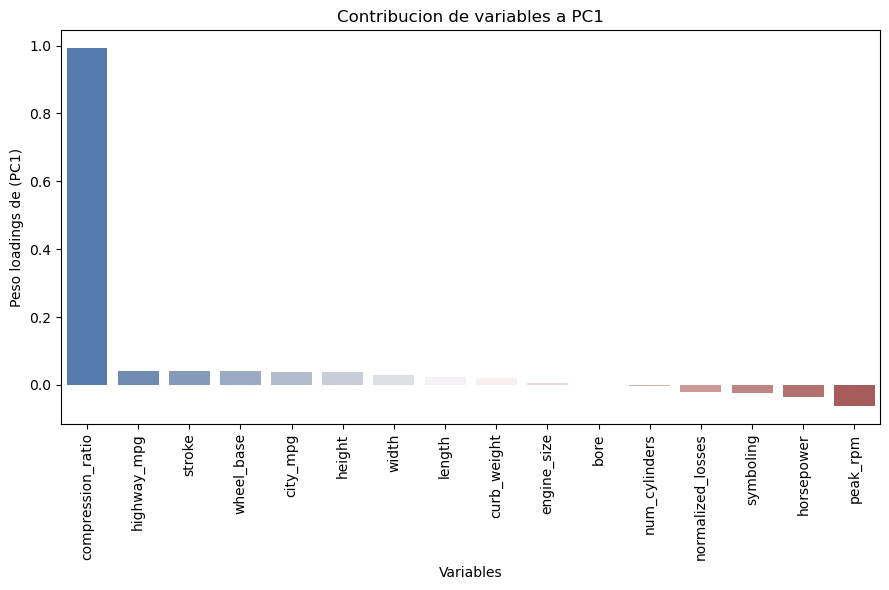

In [19]:
# Pesos de cada variable en los 4 componentes
loadings = pd.DataFrame(
    pca.components_[:4].T,
    index=X.columns,
    columns=['PC1','PC2','PC3','PC4']
)

print("Cargas (loadings) - pesos de cada variable original en los componentes:\n")
display(loadings.round(3))


principales_componentes_pca = {'PC1', 'PC2', 'PC3', 'PC4'}
for pc in principales_componentes_pca:
    print("Top 5 variables más influyentes en {pc}:")
    print(loadings[pc].abs().sort_values(ascending=False).head(5))


pc1_loadings = loadings['PC1'].sort_values(ascending=False)
plt.figure(figsize=(9, 6))
sns.barplot(
    x=pc1_loadings.index, 
    y=pc1_loadings.values, 
    hue=pc1_loadings.index,
    palette="vlag", 
    legend=False
)
plt.xticks(rotation=90)
plt.ylabel("Peso loadings de (PC1)")
plt.xlabel("Variables")
plt.title("Contribucion de variables a PC1")
plt.tight_layout()
plt.show()
plt.close()


9. Codifica las variables categóricas mediante *One-Hot Encoding* y utiliza el parámetro `drop='first'` para evitar problemas de multicolinealidad entre las variables dummy generadas.

In [20]:
# Columnas categóricas
columnas_categoricas = cars_df.select_dtypes(exclude=[np.number]).columns.tolist()
print("Columnas categóricas detectadas: ", columnas_categoricas)

X_categoricas = cars_df[columnas_categoricas].astype('string').fillna('NA') if columnas_categoricas else pd.DataFrame(index=cars_df.index)

# One-Hot Encoding y utiliza el parámetro drop='first'
ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
ohe_array = ohe.fit_transform(X_categoricas)
ohe_feature_names = ohe.get_feature_names_out(columnas_categoricas)

ohe_df = pd.DataFrame(ohe_array, index=cars_df.index, columns=ohe_feature_names)

print("-" * 50)
print(f"Número de características categóricas generadas: {ohe_df.shape[1]}")
print("-" * 50)
print("DataFrame codificado (Primeras y Últimas 5 filas):")
ohe_df

Columnas categóricas detectadas:  ['make', 'fuel_type', 'aspiration', 'num_doors', 'body_style', 'drive_wheels', 'engine_location', 'engine_type', 'fuel_system']
--------------------------------------------------
Número de características categóricas generadas: 44
--------------------------------------------------
DataFrame codificado (Primeras y Últimas 5 filas):


,make_audi,make_bmw,make_chevrolet,make_dodge,make_honda,make_isuzu,make_jaguar,make_mazda,make_mercedes-benz,make_mercury,...,engine_type_ohcf,engine_type_ohcv,engine_type_rotor,fuel_system_2bbl,fuel_system_4bbl,fuel_system_idi,fuel_system_mfi,fuel_system_mpfi,fuel_system_spdi,fuel_system_spfi
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
201,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
202,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
203,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


10. Conjunta, en un dataframe, las valores proyectados en los componentes seleccionados (mínimo), las transformaciones obtenidas de las variables categóricas y la variable de salida.
* Almacena el dataframe resultante en archivo.

In [21]:
# Conjuntar Dataframe Final
# Renombrar la variable objetivo para la concatenación
y_df = pd.DataFrame(y.values, columns=['price'], index=cars_df.index)

# Aplicar PCA (n=4 componentes)
pca = PCA(n_components=4)
X_pca_array = pca.fit_transform(X_robust_scaled)
component_names = [f'PC{i+1}' for i in range(4)]
X_pca = pd.DataFrame(X_pca_array, columns=component_names, index=cars_df.index)

# Concatenar PC's (X_pca), Categóricas (X_encoded), y Target (y_df)
df_final = pd.concat([X_pca, ohe_df, y_df], axis=1)

# Almacenar el dataframe resultante
final_file_name = 'df_modelado_final.csv'
df_final.to_csv(final_file_name, index=False)

print(f"DataFrame final de modelado creado con {df_final.shape[1]} características y {df_final.shape[0]} filas.")
print(f"Las primeras 5 filas del DataFrame final han sido guardadas en '{final_file_name}'.")
print("\nPrimeras 5 filas del DataFrame final:")

df_final


DataFrame final de modelado creado con 49 características y 205 filas.
Las primeras 5 filas del DataFrame final han sido guardadas en 'df_modelado_final.csv'.

Primeras 5 filas del DataFrame final:


,PC1,PC2,PC3,PC4,make_audi,make_bmw,make_chevrolet,make_dodge,make_honda,make_isuzu,...,engine_type_ohcv,engine_type_rotor,fuel_system_2bbl,fuel_system_4bbl,fuel_system_idi,fuel_system_mfi,fuel_system_mpfi,fuel_system_spdi,fuel_system_spfi,price
0,-1.672330,-0.722529,0.517558,-2.005139,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,13495.0
1,-1.672330,-0.722529,0.517558,-2.005139,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,16500.0
2,-1.500394,1.153782,1.224421,-0.107784,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,16500.0
3,-0.225087,-0.294445,0.871470,0.495030,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,13950.0
4,-2.760335,1.068448,1.044200,0.275985,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-0.685923,1.521444,-1.756767,0.447934,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,16845.0
201,-1.731172,2.097988,-1.648953,0.427650,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,19045.0
202,-1.659238,2.894967,-1.471049,-1.096868,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,21485.0
203,16.150045,1.937360,-0.015536,-0.496981,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,22470.0
